# **Lab 3: การวิเคราะห์การเปลี่ยนแปลงพื้นที่สีเขียวโดยใช้ NDVI จากข้อมูลดาวเทียมหลายช่วงเวลา**

# 1 Introduction

#### การเปลี่ยนแปลงของพื้นที่สีเขียวเป็นตัวชี้วัดสำคัญที่ใช้ในการศึกษาสภาพแวดล้อม การใช้ที่ดิน และการจัดการทรัพยากรธรรมชาติ พื้นที่สีเขียว เช่น ป่าไม้และพื้นที่เกษตรกรรม มีบทบาทสำคัญต่อระบบนิเวศ การดูดซับคาร์บอน และการรักษาความสมดุลของภูมิอากาศ

#### ในปัจจุบัน เทคโนโลยีภาพถ่ายจากดาวเทียมทำให้นักวิจัยสามารถติดตามการเปลี่ยนแปลงของพืชพรรณได้อย่างต่อเนื่องในระดับพื้นที่กว้าง การใช้ดัชนีพืชพรรณ เช่น NDVI (Normalized Difference Vegetation Index) ช่วยให้สามารถประเมินความหนาแน่นของพืชพรรณบนพื้นผิวโลกได้อย่างมีประสิทธิภาพ

#### **NDVI = (NIR - RED) / (NIR + RED)**

#### ค่า NDVI มีช่วงตั้งแต่ -1 ถึง 1 โดยค่าที่สูงแสดงถึงพื้นที่ที่มีพืชพรรณหนาแน่น เช่น ป่าไม้หรือพื้นที่เกษตรกรรม ขณะที่ค่าต่ำมักแสดงถึงพื้นที่ที่ไม่มีพืชพรรณ เช่น เมือง น้ำ หรือดิน

#### เพื่อวิเคราะห์การเปลี่ยนแปลงของ NDVI ในจังหวัดนครนายก โดยใช้ข้อมูลจากสองช่วงเวลา ได้แก่ ปี 2024 และ 2025

#### จังหวัดนครนายกเป็นพื้นที่ศึกษามีพิกัด UTM 47N ระหว่าง 706540 E ถึง 770275 E และ 1544228 N ถึง 1605162 N มีเนื้อที่ 2,122 ตารางกิโลเมตร มีพื้นที่ติดจังหวัดโดยรอบ ได้แก่ ทิศเหนือติดจังหวัดนครราชสีมาและสระบุรี ทิศตะวันออกติดจังหวัดปราจีนบุรี ทิศใต้ติดจังหวัดฉะเชิงเทรา และทิศตะวันตกติดจังหวัดปทุมธานี ลักษณะการใช้ประโยชน์ที่ดินหลักเป็นสถานที่ท่องเที่ยวทางธรรมชาติเเละการปลูกพืชไร่พืชสวนผลไม้เป็นหลักข้อมูลที่ใช้ในงานวิจัยประกอบด้วยข้อมูลภาพถ่ายจากดาวเทียม Landsat 8 จาก Google Earth Engine (GEE) จุดภาพได้รับการปรับให้เป็นค่าการสะท้อนแสง (reflectance) ในระดับใต้ชั้นบรรยากาศ (bottom-of-atmosphere: BOA) เป็นภาพในช่วงเดือน มกราคมถึงมีนาคมของปี 2024 เเละ 2025 โดยมีระบบพื้นหลักฐานอ้างอิงแบบ World Geodetic System 1984 (WGS1984) และระบบพิกัดแบบ Universal Transverse Mercator (UTM) Zone 47 North ความละเอียดเชิงพื้นที่ของภาพถ่ายมีขนาด 30 × 30 ตารางเมตร เลือกช่วงคลื่นจํานวนทั้งหมด 2 ช่วงคลื่น ได้แก่ B4 (red) และ B5 (NIR)

# 2 Data and Methods
### 2.1 Data

### ข้อมูลที่ใช้ประกอบด้วย

#### Vector Data

#### ขอบเขตพื้นที่ศึกษา (ROI polygon)

#### Raster Data

#### Landsat 8 imagery ปี 2024

#### Landsat 8 imagery ปี 2025

#### DEM

#### เนื่องจากไฟล์ภาพถ่ายจากดาวเทียม Landsat 8 มีขนาดใหญ่เกินไปที่จะอัพให้คุณบน Github ผมจึงสร้าง Google Drive เพื่อให้คุณสามารถดาวน์โหลด ไปเปลี่ยน path ได้ https://drive.google.com/drive/folders/1Oemfvb0vUGZS_J1y2aPuHH3A9BU6uHrn?usp=sharing

## 2.2 Tools

### เครื่องมือที่ใช้

#### Python

#### GeoPandas

#### numpy

#### Rasterio

#### Matplotlib

#### Folium

#### Google Earth Engine

# 3 Methodology

## 3.1 Load Libraries

In [81]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
import folium

## 3.2 Load Data

In [82]:
path_img_prev = '/home/lenovo/Downloads/data_lab3/Nakhon_Nayok_2024_LS8.tif'
path_img_curr = '/home/lenovo/Downloads/data_lab3/Nakhon_Nayok_2025_LS8.tif'
path_dem = '/home/lenovo/Downloads/data_lab3/DEM_Nakhon_Nayok.tif'
path_roi = '/home/lenovo/Downloads/data_lab3/Nakhon_Nayok_roi.shp'

roi = gpd.read_file(path_roi)

img_prev = rasterio.open(path_img_prev)
img_curr = rasterio.open(path_img_curr)
dem = rasterio.open(path_dem)

## 3.2.1 Study Area

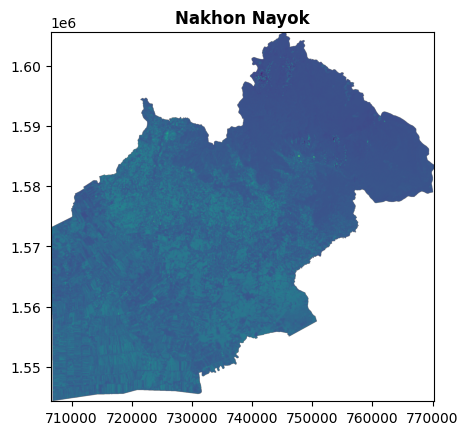

<Axes: title={'center': 'Nakhon Nayok'}>

In [83]:
show(img_prev, title="Nakhon Nayok")

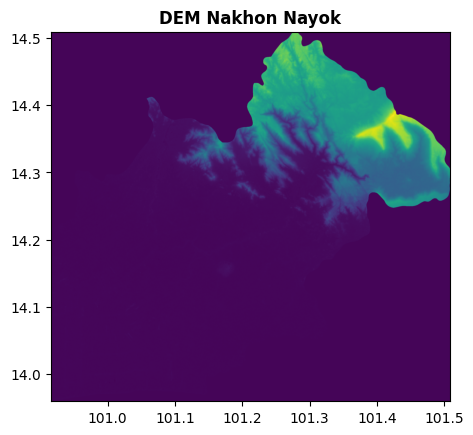

<Axes: title={'center': 'DEM Nakhon Nayok'}>

In [84]:
show(dem, title="DEM Nakhon Nayok")

## 3.3 Metadata Inspection

In [85]:
print("CRS:", img_prev.crs)
print("Resolution:", img_prev.res)
print("Width:", img_prev.width)
print("Height:", img_prev.height)
print("Number of Bands:", img_prev.count)

CRS: EPSG:32647
Resolution: (30.0, 30.0)
Width: 2126
Height: 2048
Number of Bands: 19


In [86]:
print("CRS:", img_curr.crs)
print("Resolution:", img_curr.res)
print("Width:", img_curr.width)
print("Height:", img_curr.height)
print("Number of Bands:", img_curr.count)

CRS: EPSG:32647
Resolution: (30.0, 30.0)
Width: 2126
Height: 2048
Number of Bands: 19


In [87]:
print("CRS:", dem.crs)
print("Resolution:", dem.res)
print("Width:", dem.width)
print("Height:", dem.height)
print("Number of Bands:", dem.count)

CRS: EPSG:4326
Resolution: (0.00026949458523585647, 0.00026949458523585647)
Width: 2201
Height: 2038
Number of Bands: 1


In [88]:
print("===== Metadata Sentinel 2024 =====")
print(img_prev.meta)

print("\n===== Metadata Sentinel 2025 =====")
print(img_curr.meta)

print("\n===== Metadata DEM =====")
print(dem.meta)

===== Metadata Sentinel 2024 =====
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': -inf, 'width': 2126, 'height': 2048, 'count': 19, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]'), 'transform': Affine(30.0, 0.0, 706500.0,
       0.0, -30.0, 1605690.0)}

===== Metadata Sentinel 2025 =====
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': -inf, 'width': 2126, 'height': 2048, 'count': 19, 'crs': CRS.from_wkt('PROJCS["WGS 84

## 3.4 Extract Bands

### Landsat 8

### Band
### B4 = Red
### B5 = NIR

In [89]:
red_prev = img_prev.read(4)
nir_prev = img_prev.read(5)

red_curr = img_curr.read(4)
nir_curr = img_curr.read(5)

## 3.5 Calculate NDVI

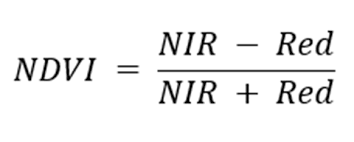

In [90]:
ndvi_prev = (nir_prev - red_prev) / (nir_prev + red_prev)
ndvi_curr = (nir_curr - red_curr) / (nir_curr + red_curr)

/tmp/ipykernel_61629/655046956.py:1: RuntimeWarning: invalid value encountered in subtract
  ndvi_prev = (nir_prev - red_prev) / (nir_prev + red_prev)
/tmp/ipykernel_61629/655046956.py:2: RuntimeWarning: invalid value encountered in subtract
  ndvi_curr = (nir_curr - red_curr) / (nir_curr + red_curr)


## 3.6 NDVI Map

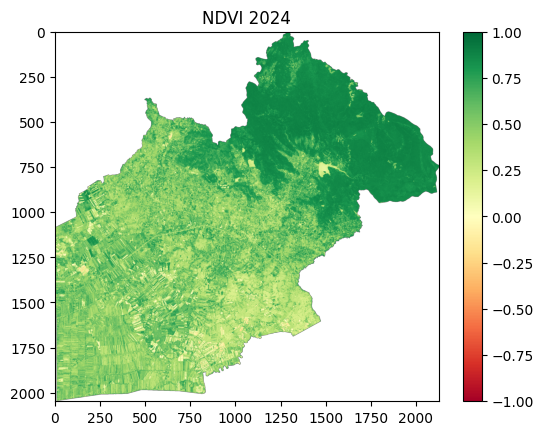

In [91]:
plt.imshow(ndvi_prev, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar()
plt.title("NDVI 2024")
plt.show()

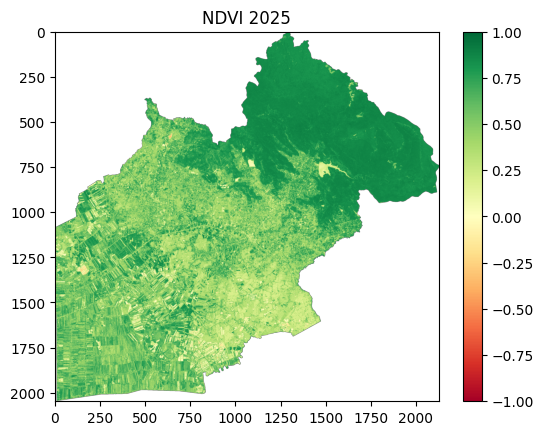

In [92]:
plt.imshow(ndvi_curr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar()
plt.title("NDVI 2025")
plt.show()

## 3.7 NDVI Change Detection

In [93]:
delta_ndvi = ndvi_curr - ndvi_prev

## 3.8 Change Map

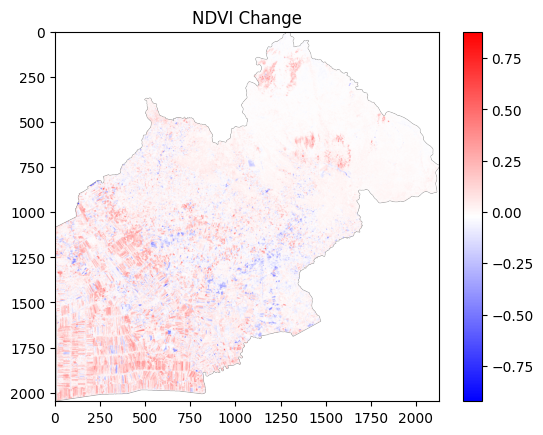

In [94]:
plt.imshow(delta_ndvi, cmap='bwr')
plt.colorbar()
plt.title("NDVI Change")
plt.show()

## 3.9 Histogram

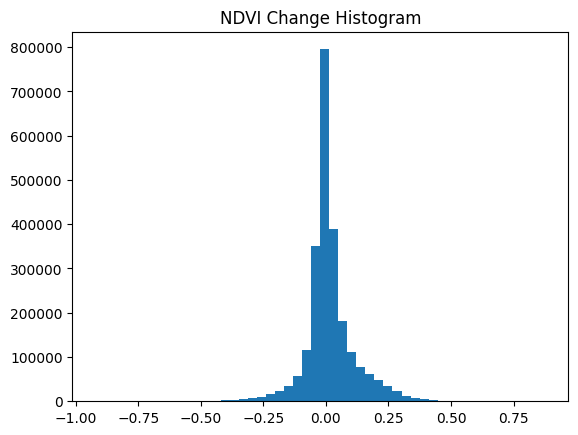

In [108]:
plt.hist(delta_ndvi.flatten(), bins=50)
plt.title("NDVI Change Histogram")
plt.show()

## 3.10 DEM Analysis

In [96]:
from rasterio.warp import reproject, Resampling
import numpy as np

# สร้าง array ใหม่ขนาดเท่า NDVI
dem_resampled = np.empty_like(ndvi_curr)

reproject(
    source=rasterio.band(dem, 1),
    destination=dem_resampled,
    src_transform=dem.transform,
    src_crs=dem.crs,
    dst_transform=img_curr.transform,
    dst_crs=img_curr.crs,
    resampling=Resampling.bilinear
)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(2048, 2126)),
 Affine(30.0, 0.0, 706500.0,
        0.0, -30.0, 1605690.0))

In [97]:
print(dem_resampled.shape)
print(ndvi_curr.shape)

(2048, 2126)
(2048, 2126)


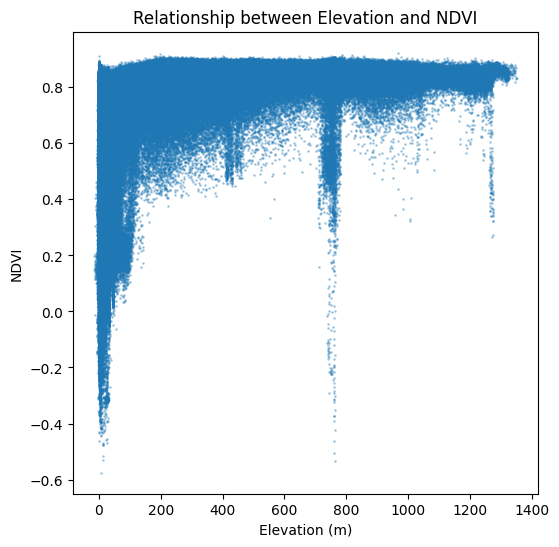

In [98]:
plt.figure(figsize=(6,6))

plt.scatter(
    dem_resampled.flatten(),
    ndvi_curr.flatten(),
    s=1,
    alpha=0.3
)

plt.xlabel("Elevation (m)")
plt.ylabel("NDVI")
plt.title("Relationship between Elevation and NDVI")

plt.show()

In [99]:
from rasterio.warp import reproject, Resampling

dem_resampled = np.empty_like(ndvi_curr)

reproject(
    source=rasterio.band(dem, 1),
    destination=dem_resampled,
    src_transform=dem.transform,
    src_crs=dem.crs,
    dst_transform=img_curr.transform,
    dst_crs=img_curr.crs,
    resampling=Resampling.bilinear
)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(2048, 2126)),
 Affine(30.0, 0.0, 706500.0,
        0.0, -30.0, 1605690.0))

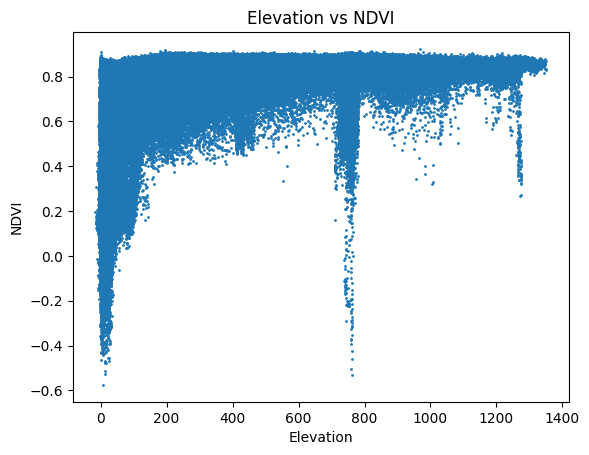

In [100]:
plt.scatter(dem_resampled.flatten(), ndvi_curr.flatten(), s=1)

plt.xlabel("Elevation")
plt.ylabel("NDVI")
plt.title("Elevation vs NDVI")
plt.show()

In [101]:
from rasterio.warp import reproject, Resampling
import numpy as np

# อ่าน DEM
elevation = dem.read(1)

# สร้าง array ใหม่ขนาดเท่ากับ NDVI
dem_resampled = np.empty_like(ndvi_curr)

reproject(
    source=elevation,
    destination=dem_resampled,
    src_transform=dem.transform,
    src_crs=dem.crs,
    dst_transform=img_curr.transform,
    dst_crs=img_curr.crs,
    resampling=Resampling.bilinear
)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(2048, 2126)),
 Affine(30.0, 0.0, 706500.0,
        0.0, -30.0, 1605690.0))

In [102]:
print(dem_resampled.shape)
print(ndvi_curr.shape)

(2048, 2126)
(2048, 2126)


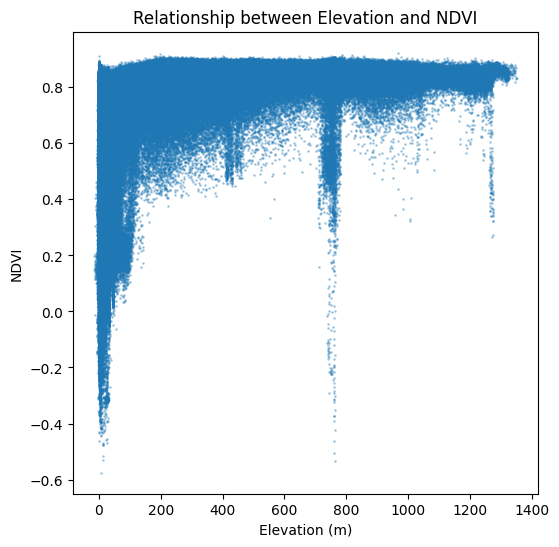

In [103]:
elev_flat = dem_resampled.flatten()
ndvi_flat = ndvi_curr.flatten()

mask = (~np.isnan(elev_flat)) & (~np.isnan(ndvi_flat))

plt.figure(figsize=(6,6))

plt.scatter(
    elev_flat[mask],
    ndvi_flat[mask],
    s=1,
    alpha=0.3
)

plt.xlabel("Elevation (m)")
plt.ylabel("NDVI")
plt.title("Relationship between Elevation and NDVI")

plt.show()

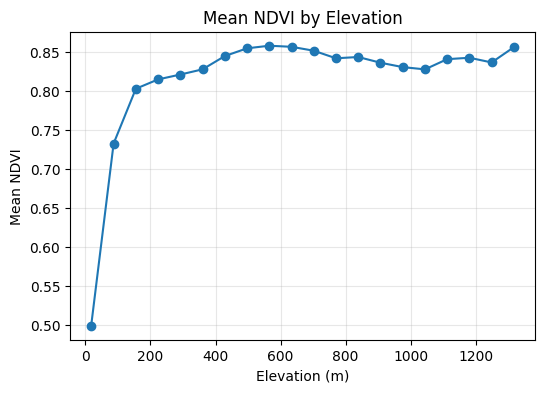

In [104]:
df = pd.DataFrame({
    "elevation": elev_flat,
    "ndvi": ndvi_flat
})

df = df.dropna()

# สร้าง bin ความสูง
df["elev_bin"] = pd.cut(df["elevation"], bins=20)

# คำนวณค่า NDVI เฉลี่ย
mean_ndvi = df.groupby("elev_bin", observed=False)["ndvi"].mean()

# เอาค่ากลางของช่วงมาใช้เป็นแกน x
x = [interval.mid for interval in mean_ndvi.index]

plt.figure(figsize=(6,4))

plt.plot(x, mean_ndvi.values, marker="o")

plt.xlabel("Elevation (m)")
plt.ylabel("Mean NDVI")
plt.title("Mean NDVI by Elevation")

plt.grid(alpha=0.3)

plt.show()

## **การวิเคราะห์ปัจจัยที่ส่งผลต่อ NDVI**

### การเปลี่ยนแปลงของค่า NDVI อาจได้รับอิทธิพลจากหลายปัจจัย เช่น

### **1.ฤดูกาล (Seasonality)**
### พืชพรรณมีการเปลี่ยนแปลงตามฤดูกาล โดยช่วงฤดูฝนหรือช่วงที่พืชกำลังเจริญเติบโตจะมีค่า NDVI สูงกว่า

### **2.การใช้ประโยชน์ที่ดิน (Land Use)**
### พื้นที่เกษตรกรรมมีการเปลี่ยนแปลงของ NDVI ตามรอบการเพาะปลูก การเก็บเกี่ยว และการเตรียมพื้นที่เพาะปลูก

### **3.สภาพภูมิอากาศ (Climate Conditions)**
### ปริมาณน้ำฝน อุณหภูมิ และความชื้นในดินสามารถส่งผลต่อการเจริญเติบโตของพืชพรรณ และส่งผลต่อค่า NDVI

### **4.กิจกรรมของมนุษย์ (Human Activities)**
### เช่น การขยายตัวของชุมชน การพัฒนาโครงสร้างพื้นฐาน หรือการเปลี่ยนแปลงพื้นที่เกษตรกรรม

# **คำถามท้าย Lab**

### **1. ทำไมการวิเคราะห์ NDVI จากภาพถ่ายดาวเทียมหลายช่วงเวลาจึงมีความสำคัญ?**

### การวิเคราะห์ NDVI จากภาพถ่ายดาวเทียมหลายช่วงเวลามีความสำคัญ เพราะ ช่วยให้สามารถติดตามการเปลี่ยนแปลงของพืชพรรณในระยะยาวได้ การเปรียบเทียบค่า NDVI ในช่วงเวลาที่ต่างกันทำให้สามารถสังเกตแนวโน้มของพื้นที่สีเขียว เช่น การเพิ่มขึ้นของพื้นที่เกษตรกรรม หรือการลดลงของพื้นที่ป่าไม้ตัวอย่างเช่น หากพื้นที่หนึ่งมีค่า NDVI สูงในปีหนึ่ง แต่ลดลงอย่างชัดเจนในปีถัดมา อาจบ่งบอกถึงการตัดไม้ทำลายป่า หรือการพัฒนาเมือง ดังนั้นการใช้ข้อมูลหลายช่วงเวลาจึงช่วยให้สามารถเข้าใจการเปลี่ยนแปลงของสิ่งแวดล้อมได้ดีขึ้น และสามารถนำไปใช้ในการวางแผนการใช้ที่ดินหรือการอนุรักษ์ทรัพยากรธรรมชาติได้อย่างมีประสิทธิภาพ

### **2. พื้นที่ที่มีการเปลี่ยนแปลง NDVI อย่างมีนัยสำคัญควรได้รับการตรวจสอบเพิ่มเติมอย่างไร?**

### พื้นที่ที่มีการเปลี่ยนแปลง NDVI อย่างมีนัยสำคัญควรได้รับการตรวจสอบเพิ่มเติมโดยใช้ข้อมูลอื่นประกอบ เช่น ภาพถ่ายจากดาวเทียมความละเอียดสูง ข้อมูลการใช้ที่ดิน หรือการสำรวจภาคสนาม ตัวอย่างเช่น หากพบว่าพื้นที่หนึ่งมีค่า NDVI ลดลงอย่างรวดเร็ว อาจต้องตรวจสอบว่าพื้นที่ดังกล่าวถูกเปลี่ยนเป็นพื้นที่เกษตรกรรม พื้นที่เมือง หรือเกิดจากภัยธรรมชาติ เช่น ไฟป่า การตรวจสอบเพิ่มเติมช่วยให้สามารถระบุสาเหตุที่แท้จริงของการเปลี่ยนแปลงได้

### **3. ปัจจัยใดที่อาจทำให้ค่า NDVI เปลี่ยนแปลงโดยไม่เกี่ยวข้องกับการเปลี่ยนแปลงของพืชพรรณ?**

### ค่า NDVI อาจเปลี่ยนแปลงได้จากหลายปัจจัยที่ไม่ได้เกี่ยวข้องกับการเปลี่ยนแปลงของพืชพรรณโดยตรง เช่น สภาพอากาศ เมฆ หมอก หรือความแตกต่างของฤดูกาล ตัวอย่างเช่น หากภาพถ่ายจากดาวเทียมถูกถ่ายในฤดูแล้ง ค่า NDVI อาจต่ำกว่าภาพที่ถ่ายในฤดูฝน แม้ว่าพื้นที่นั้นจะยังคงเป็นป่าเหมือนเดิม ดังนั้นจึงควรเลือกข้อมูลภาพถ่ายจากดาวเทียมในช่วงฤดูกาลเดียวกันเพื่อลดความคลาดเคลื่อนของการวิเคราะห์

### **4. หากต้องการเพิ่มความแม่นยำของการวิเคราะห์การเปลี่ยนแปลง NDVI ควรใช้เทคนิคอะไรเพิ่มเติม?**

### หากต้องการเพิ่มความแม่นยำในการวิเคราะห์ NDVI สามารถใช้เทคนิคเพิ่มเติม เช่น การใช้ภาพหลายช่วงเวลา (multi-temporal analysis) การใช้ข้อมูลดาวเทียมความละเอียดสูง หรือการใช้เทคนิค machine learning เพื่อจำแนกประเภทการใช้ที่ดิน ตัวอย่างเช่น การใช้ข้อมูลจากหลายปีติดต่อกันสามารถช่วยลดผลกระทบจากความผิดพลาดของภาพถ่ายดาวเทียมเพียงภาพเดียว และช่วยให้สามารถวิเคราะห์แนวโน้มของพืชพรรณได้แม่นยำยิ่งขึ้น

### **5. ทำไมการใช้ DEM จึงช่วยให้เข้าใจบริบทของ NDVI ได้ดีขึ้น?**

### DEM ช่วยให้เข้าใจบริบทของ NDVI ได้ดีขึ้น เพราะ ภูมิประเทศมีผลต่อการเจริญเติบโตของพืชพรรณ เช่น พื้นที่ที่มีความสูงมากอาจมีอุณหภูมิต่ำกว่าและมีความชื้นมากกว่า ซึ่งส่งผลต่อชนิดและความหนาแน่นของพืช ตัวอย่างเช่น พื้นที่ภูเขามักมีป่าไม้หนาแน่นและมีค่า NDVI สูง ในขณะที่พื้นที่ราบอาจถูกใช้เป็นพื้นที่เกษตรกรรมหรือชุมชน ซึ่งมีค่า NDVI ต่ำกว่า ดังนั้นการใช้ DEM ร่วมกับ NDVI จึงช่วยให้สามารถวิเคราะห์ความสัมพันธ์ระหว่างภูมิประเทศและพืชพรรณได้ดียิ่งขึ้น

## **สรุปผล**

### ดัชนีพืชพรรณปกคลุมดิน (Normalized Difference Vegetation Index: NDVI) เป็นตัวชี้วัดที่สำคัญในการวิเคราะห์สภาพความสมบูรณ์ของพืชพรรณจากข้อมูลภาพถ่ายดาวเทียม โดยคำนวณจากค่าการสะท้อนแสงในช่วงคลื่นสีแดง (Red) และช่วงคลื่นใกล้อินฟราเรด (Near Infrared: NIR) ซึ่งช่วยให้สามารถประเมินความหนาแน่นและสุขภาพของพืชพรรณในพื้นที่ต่าง ๆ ได้อย่างมีประสิทธิภาพ
### จากแผนที่ NDVI ของปี 2024 และ 2025 พบว่าพื้นที่ส่วนใหญ่ของจังหวัดนครนายกมีค่า NDVI อยู่ในระดับค่อนข้างสูง โดยเฉพาะบริเวณพื้นที่ภูเขาทางตอนเหนือและตะวันออกของจังหวัด ซึ่งมีลักษณะเป็นพื้นที่ป่าไม้ อุทยานเเห่งชาติเขาใหญ่ ส่งผลให้มีค่าดัชนีพืชพรรณอยู่ในระดับสูงอย่างต่อเนื่องในทั้งสองช่วงเวลา

### ในทางตรงกันข้าม พื้นที่บริเวณตอนใต้และตะวันตกของจังหวัดซึ่งเป็นพื้นที่เกษตรกรรมและพื้นที่ชุมชน มีค่า NDVI อยู่ในระดับปานกลางถึงค่อนข้างต่ำ เนื่องจากเป็นพื้นที่ที่มีการใช้ประโยชน์ที่ดินเพื่อการเกษตรหรือกิจกรรมของมนุษย์ ซึ่งทำให้ความหนาแน่นของพืชพรรณไม่สูงเท่าพื้นที่ป่าไม้

### จากแผนที่การเปลี่ยนแปลงของ NDVI (NDVI Change) พบว่าการเปลี่ยนแปลงส่วนใหญ่มีค่าใกล้ศูนย์ แสดงให้เห็นว่าพื้นที่ส่วนใหญ่ไม่มีการเปลี่ยนแปลงของพืชพรรณอย่างมีนัยสำคัญ อย่างไรก็ตาม มีบางบริเวณที่แสดงการเพิ่มขึ้นของค่า NDVI ซึ่งอาจเกิดจากการเจริญเติบโตของพืชพรรณตามฤดูกาลหรือการฟื้นตัวของพื้นที่ป่า ในขณะที่บางพื้นที่มีค่า NDVI ลดลง ซึ่งอาจเกี่ยวข้องกับกิจกรรมทางการเกษตร การเปลี่ยนแปลงการใช้ที่ดิน หรือสภาพอากาศในช่วงเวลานั้น

### จากกราฟ Histogram ของค่า NDVI Change พบว่าค่าการเปลี่ยนแปลงส่วนใหญ่กระจุกตัวอยู่ใกล้กับค่า 0 ซึ่งหมายความว่าพื้นที่ส่วนใหญ่มีการเปลี่ยนแปลงของพืชพรรณเพียงเล็กน้อยระหว่างปี 2024 และ 2025

### ลักษณะการกระจายตัวของกราฟมีลักษณะคล้ายรูปทรงระฆัง (bell-shaped distribution) โดยมีค่าการเปลี่ยนแปลงทั้งในทิศทางบวกและลบ แสดงให้เห็นว่าบางพื้นที่มีพืชพรรณเพิ่มขึ้น ในขณะที่บางพื้นที่มีพืชพรรณลดลง ตัวอย่างเช่น พื้นที่เกษตรกรรมบางส่วนอาจมีค่า NDVI เพิ่มขึ้นเนื่องจากการปลูกพืชในช่วงฤดูกาลเพาะปลูก ในขณะที่พื้นที่ที่มีการเก็บเกี่ยวหรือการเตรียมดินอาจมีค่า NDVI ลดลง

### จากการวิเคราะห์ค่า NDVI เฉลี่ยตามระดับความสูง พบว่าเมื่อระดับความสูงเพิ่มขึ้น ค่า NDVI มีแนวโน้มเพิ่มขึ้นในช่วงระดับความสูงต่ำถึงปานกลาง และมีค่าค่อนข้างคงที่ในพื้นที่ที่มีความสูงมากกว่า

### ผลการวิเคราะห์นี้สามารถอธิบายได้จากลักษณะการใช้ที่ดินของพื้นที่จังหวัดนครนายก โดยพื้นที่ที่มีระดับความสูงต่ำมักเป็นพื้นที่เกษตรกรรมและพื้นที่ชุมชน ซึ่งมีความหลากหลายของการใช้ที่ดินและพืชพรรณ ส่งผลให้ค่า NDVI มีความแปรปรวนสูง ในขณะที่พื้นที่ที่มีระดับความสูงมาก เช่น พื้นที่ภูเขาและพื้นที่ป่าไม้ มักมีพืชพรรณธรรมชาติที่มีความหนาแน่นสูง ทำให้ค่า NDVI อยู่ในระดับสูงและมีความสม่ำเสมอมากกว่า